In [1]:
#@title Libraries
print("Loading Libraries")

import copy
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys
import timm
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from collections import defaultdict, OrderedDict
from sklearn.metrics import auc, classification_report, confusion_matrix, roc_curve
from torchsummary import summary
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision.datasets import ImageFolder
from tqdm.notebook import tqdm
import random
#!pip install torchview
#from torchview import draw_graph

print("Libraries Loaded")

Loading Libraries
Libraries Loaded


In [2]:
#@title Parameters

# ===== Parámetros generales =====
train_pct          = 0.8    #@param {type:"number"}
val_pct            = 0.1    #@param {type:"number"}
test_pct            = 0.1   #@param {type:"number"}
seed               = 42     #@param {type:"number"}
var_batch_size     = 16     #@param {type:"number"}
num_epochs         = 100     #@param {type:"number"}
patience           = 15     #@param {type:"number"}
var_kernel_size    = 3      #@param {type:"number"}
learning_rate      = 0.0001  #@param {type:"number"}

# ===== Parámetros Preparación de imágenes =====
balancear_por_clase = True  #@param {type:"boolean"}
image_width        = 224    #@param {type:"number"}
image_height       = 224    #@param {type:"number"}
# Data Augmentation:
use_flip            = True  #@param {type:"boolean"}
flip_probability    = 0.6   #@param {type:"number"}
use_rotation        = True  #@param {type:"boolean"}
rotation_degrees    = 20    #@param {type:"number"}
use_color_jitter    = True  #@param {type:"boolean"}
brightness_factor   = 0.2   #@param {type:"number"}
contrast_factor     = 0.3   #@param {type:"number"}
saturation_factor   = 0.1   #@param {type:"number"}


In [3]:
#@title Define structures for: Dataset, Early Stopping & Eye Disease Classifier
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0, mode='min', restore_best=True):
        """
        Utility to stop training when a monitored metric stops improving.

        Args:
            patience (int): Number of epochs to wait before stopping.
            min_delta (float): Minimum change to count as improvement.
            mode (str): 'min' for loss, 'max' for accuracy/score.
            restore_best (bool): Restore best weights after stopping.
        """
        assert mode in ('min', 'max')
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.restore_best = restore_best

        self.best_score = None
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def _is_improvement(self, current, best):
        if self.mode == 'min':
            return (best - current) > self.min_delta
        else:  # 'max'
            return (current - best) > self.min_delta

    def step(self, current_value, model):
        # Initialize best score on first call
        if self.best_score is None:
            self.best_score = current_value
            if self.restore_best:
                self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
            return False  # never stops on the first step

        if self._is_improvement(current_value, self.best_score):
            # Metric improved: reset patience and save model state
            self.best_score = current_value
            if self.restore_best:
                self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
             # Metric did not improve enough
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

    def restore(self, model):
        if self.restore_best and self.best_state is not None:
            model.load_state_dict(self.best_state)

class EyeDiseaseDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = ImageFolder(data_dir, transform=transform)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    @property
    def classes(self):
        return self.data.classes

class SimpleEyeDiseaseClassifer(nn.Module):
    def __init__(self, num_classes):
        super(SimpleEyeDiseaseClassifer, self).__init__()
         # Load pretrained EfficientNet-B0 from timm library
        self.base_model = timm.create_model('efficientnet_b0', pretrained=True)

        # Toma todas las capas del modelo base excepto la última (la cabeza clasificadora)
        # para usarlas como extractor de características (backbone).
        self.features = nn.Sequential(*list(self.base_model.children())[:-1])

        # Tamaño del último mapa de características de EfficientNet-B0 (canales).
        enet_out_size = 1280

        # Make a classifier
        self.classifier = nn.Sequential(             # Secuencia de capas para mapear features -> logits de clases.
            nn.Flatten(),                            # Aplana de [N, C, H, W] a [N, C*H*W] (aquí H=W=1 normalmente).
            nn.Linear(enet_out_size, num_classes)    # Linear layer: 1280 -> num_classes
        )

    def forward(self, x):
        x = self.features(x)                         # Salida típica: [N, 1280, 1, 1] en EfficientNet-B0
        output = self.classifier(x)                  # Aplana y proyecta a [N, num_classes].
        return output                                # Devuelve logits (sin softmax); usá CrossEntropyLoss.

In [4]:
#@title Define Network structure

class Rescaling(nn.Module):
    def __init__(self, scale=1/255.0):
        super().__init__()
        self.scale = scale
    def forward(self, x):
        return x * self.scale

class SimpleConvNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(OrderedDict([
            ("slng_1_div_255", Rescaling(1/255.0)),
            ("c_conv_1", nn.Conv2d(3, 64, kernel_size=var_kernel_size, stride=1, padding=1, bias=True)),
            ("p_conv_1", nn.MaxPool2d(kernel_size=var_kernel_size, stride=3, padding=1)),
            ("c_conv_2", nn.Conv2d(64, 32, kernel_size=var_kernel_size, stride=1, padding=1, bias=True)),
            ("p_conv_2", nn.MaxPool2d(kernel_size=var_kernel_size, stride=3, padding=1)),
            ("c_conv_3", nn.Conv2d(32, 16, kernel_size=var_kernel_size, stride=1, padding=1, bias=True)),
            ("p_conv_3", nn.MaxPool2d(kernel_size=var_kernel_size, stride=3, padding=1)),
            ("c_conv_4", nn.Conv2d(16, 8,  kernel_size=var_kernel_size, stride=1, padding=1, bias=True)),
            ("p_conv_4", nn.MaxPool2d(kernel_size=var_kernel_size, stride=3, padding=1)),
        ]))

        self.flat = nn.Flatten()
        self.lineal_1 = nn.Linear(3*3*8, 16, bias=True)  # 72 → 16
        self.output   = nn.Linear(16, num_classes, bias=True)

    def forward(self, x):
        x = self.features(x)      # (N, 8, 3, 3)
        x = self.flat(x)          # (N, 72)
        x = self.lineal_1(x)      # (N, 16)
        x = self.output(x)        # (N, 4)
        return x


In [5]:
#@title Download Dataset from Kaggle

# Download latest dataset version
path = kagglehub.dataset_download("gunavenkatdoddi/eye-diseases-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eye-diseases-classification' dataset.
Path to dataset files: /kaggle/input/eye-diseases-classification


In [6]:
#@title Identify classes

# Get the indices of each type"
data_dir = os.path.join(path,'dataset')
target_to_class = {v: k for k, v in ImageFolder(data_dir).class_to_idx.items()}
print(target_to_class)

{0: 'cataract', 1: 'diabetic_retinopathy', 2: 'glaucoma', 3: 'normal'}


{0: 'cataract', 1: 'diabetic_retinopathy', 2: 'glaucoma', 3: 'normal'}


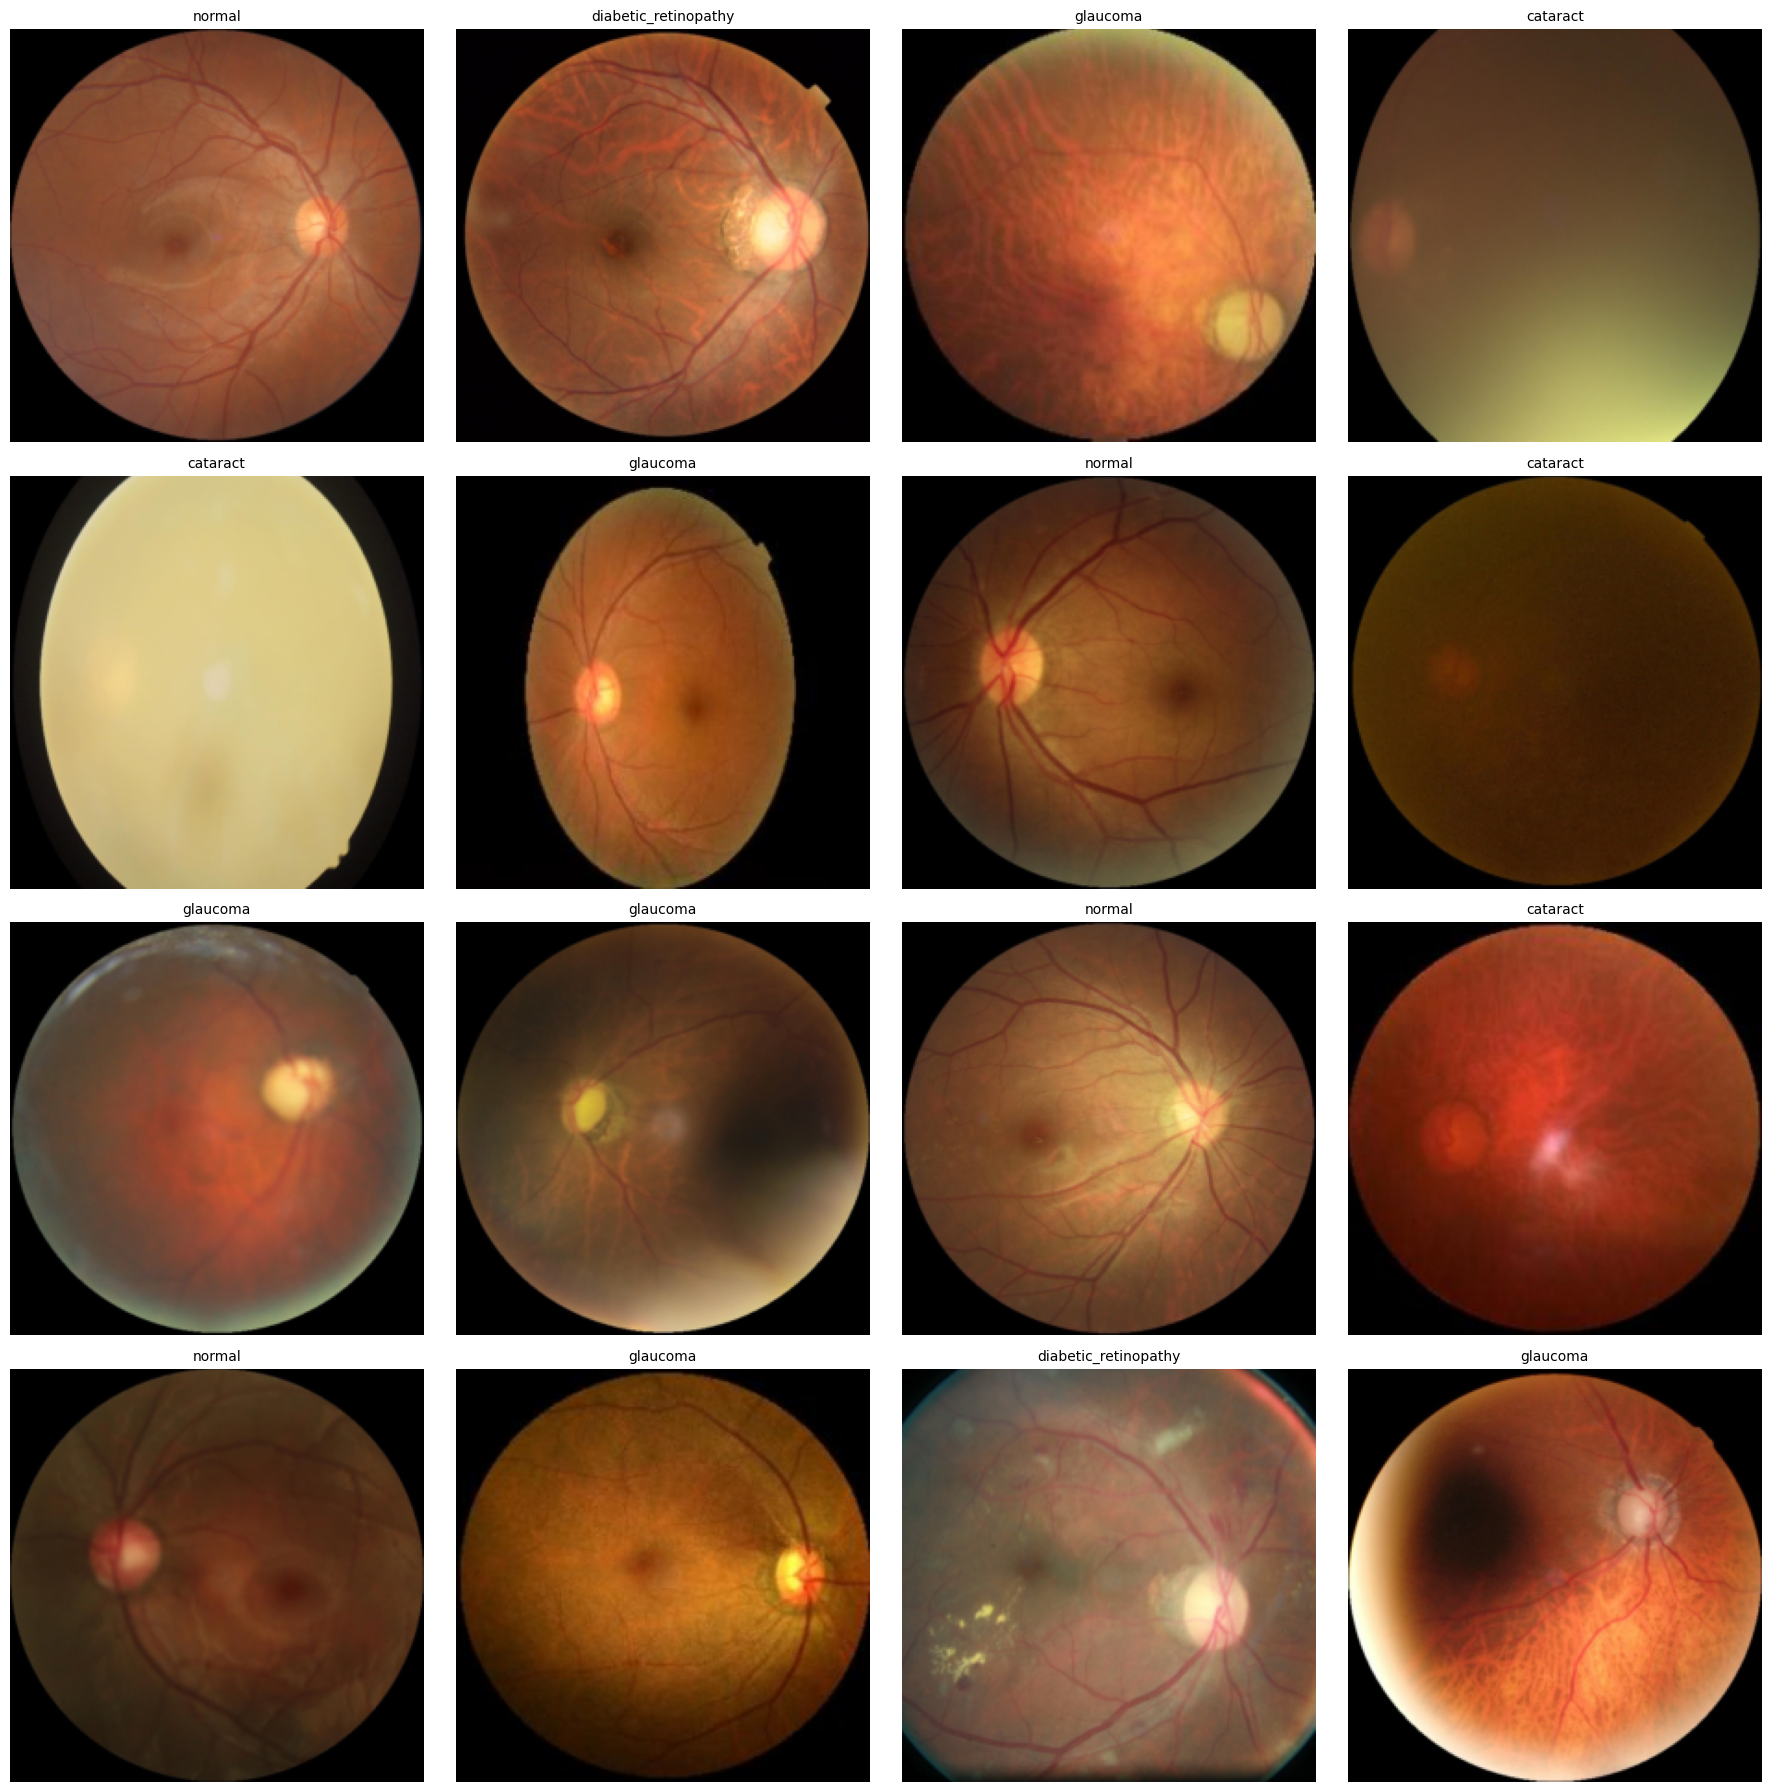

In [7]:
#@title Setup Dataset

# --- Dataset setup ---
transform = transforms.Compose([
    transforms.Resize((image_width, image_height)),
    transforms.ToTensor()
])
dataset = ImageFolder(data_dir, transform=transform)

# Build target -> class mapping
target_to_class2 = {v: k for k, v in dataset.class_to_idx.items()}
all_labels = [target_to_class2[i] for i in range(len(target_to_class2))]
print(target_to_class2)

# --- Plot 16 random images ---
fig, m_axs = plt.subplots(4, 4, figsize=(18, 18))

for i, c_ax in enumerate(m_axs.flatten()):
    idx = random.randint(0, len(dataset) - 1)
    c_x, c_y = dataset[idx]

    # Move to CPU and convert [C, H, W] -> [H, W, C]
    c_x_cpu = c_x.cpu().permute(1, 2, 0)

    # Check if image is grayscale repeated in 3 channels
    if c_x_cpu.shape[2] == 3 and torch.allclose(c_x_cpu[:,:,0], c_x_cpu[:,:,1]) and torch.allclose(c_x_cpu[:,:,1], c_x_cpu[:,:,2]):
        img_to_show = c_x_cpu[:,:,0]
        cmap = 'gray'
    else:
        img_to_show = c_x_cpu
        cmap = None

    c_ax.imshow(img_to_show, cmap=cmap)
    c_ax.set_title(target_to_class2[c_y], fontsize=10)
    c_ax.axis('off')

plt.tight_layout(pad=1.0)
plt.show()


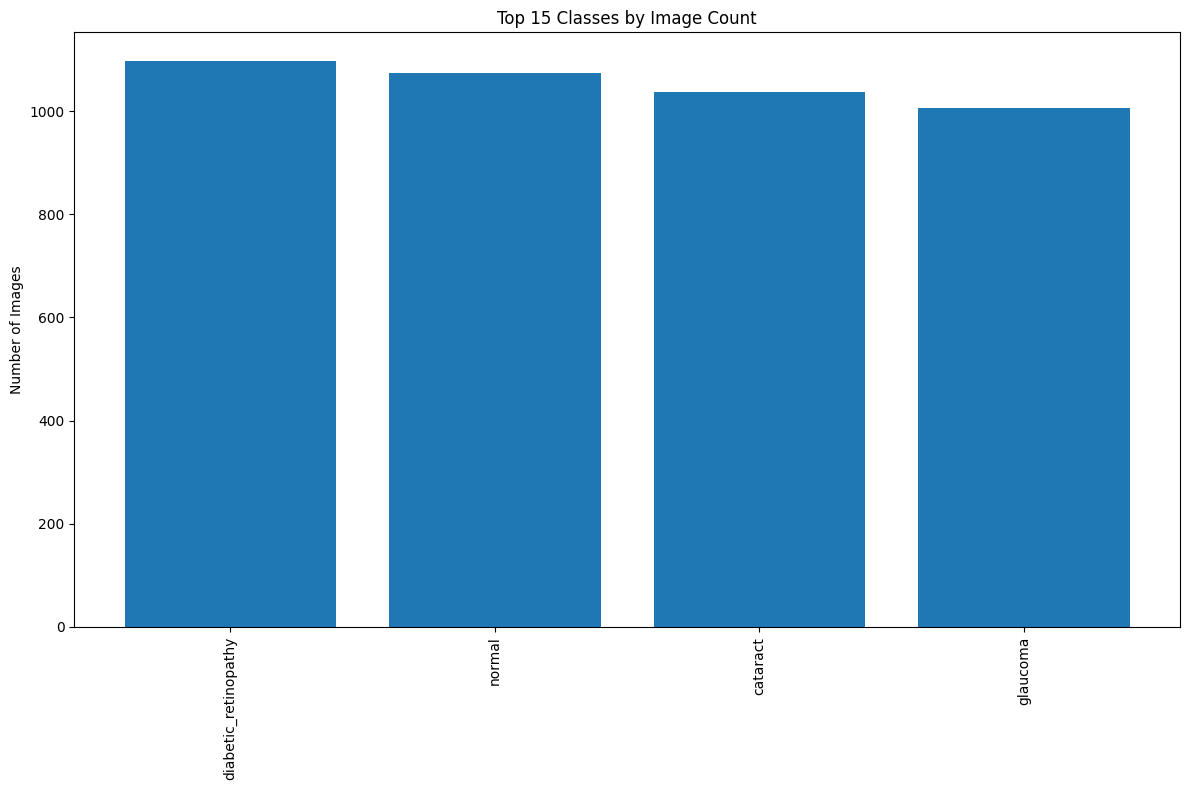

In [8]:
#@title Count images by class

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Get the original dataset without transforms
orig_dataset = ImageFolder(data_dir)  # no transforms

# Use the original dataset to get labels
all_labels = [label for _, label in orig_dataset]  # orig_dataset from ImageFolder
target_to_class = {v: k for k, v in orig_dataset.class_to_idx.items()}  # idx -> class name
all_images_classes = [target_to_class[label] for label in all_labels]   # ['cataract', 'cataract', 'cataract', 'normal', 'normal', ...]

# Count occurrences
label_counts = Counter(all_images_classes)
top_labels = label_counts.most_common(15)  # top 15

labels, counts = zip(*top_labels)

# --- Plot ---
fig, ax1 = plt.subplots(1,1,figsize=(12, 8))
ax1.bar(np.arange(len(counts))+0.5, counts)
ax1.set_xticks(np.arange(len(counts))+0.5)
ax1.set_xticklabels(labels, rotation=90, fontsize=10)
ax1.set_ylabel("Number of Images")
ax1.set_title("Top 15 Classes by Image Count")
plt.tight_layout()
plt.show()


In [9]:
#@title Transformations / Data Augmentation

# Build transforms dynamically
transform_list = [transforms.Resize((image_width, image_height))]

# Transformaciones geométricas
if use_flip:
    transform_list.append(transforms.RandomHorizontalFlip(p=flip_probability))

if use_rotation:
    transform_list.append(transforms.RandomRotation(rotation_degrees))

# Transformaciones de color
if use_color_jitter:
    color_jitter_params = {}
    if brightness_factor > 0:
        color_jitter_params['brightness'] = brightness_factor
    if contrast_factor > 0:
        color_jitter_params['contrast'] = contrast_factor
    if saturation_factor > 0:
        color_jitter_params['saturation'] = saturation_factor

    if color_jitter_params:  # Solo agregar si hay al menos un parámetro
        transform_list.append(transforms.ColorJitter(**color_jitter_params))

# Conversión final
transform_list.append(transforms.ToTensor())

# Crear el transform compuesto

import torchvision.transforms as transforms

transform = transforms.Compose(transform_list)

# OVERRIDE =============================================================================================================================================================================================================
transform = transforms.Compose([
    # Rescale: divide pixel values by 255
    transforms.ToTensor(),  # converts to [0,1] float tensor already

    transforms.Resize((image_width, image_height)),

    # Brightness adjustment (range [0.8, 1.2])
    transforms.ColorJitter(brightness=(0.8, 1.2)),

    # Random rotation within 5 degrees
    transforms.RandomRotation(degrees=5, fill=(0,)),  # fill=(0,) = 'nearest' equivalent (black fill)

    # Random horizontal flip
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225]),

    # Random zoom (implemented as RandomAffine with scale range)
    transforms.RandomAffine(
        degrees=0,  # no extra rotation
        scale=(0.9, 1.1),  # 1 ± zoom_range
        fill=(0,)
    ),
])



# ===== Información de las transformaciones aplicadas =====
print("=== TRANSFORMACIONES APLICADAS ===")
print(f"✓ Resize: {image_width}x{image_height}")

if use_flip:
    print(f"✓ Random Horizontal Flip: {flip_probability*100}% probabilidad")
else:
    print("✗ Flip: Deshabilitado")

if use_rotation:
    print(f"✓ Random Rotation: ±{rotation_degrees} grados")
else:
    print("✗ Rotation: Deshabilitado")

if use_color_jitter:
    jitter_info = []
    if brightness_factor > 0:
        jitter_info.append(f"brightness=±{brightness_factor}")
    if contrast_factor > 0:
        jitter_info.append(f"contrast=±{contrast_factor}")
    if saturation_factor > 0:
        jitter_info.append(f"saturation=±{saturation_factor}")

    if jitter_info:
        print(f"✓ Color Jitter: {', '.join(jitter_info)}")
    else:
        print("✗ Color Jitter: Sin parámetros configurados")
else:
    print("✗ Color Jitter: Deshabilitado")

print("✓ ToTensor: Siempre aplicado")

full_dataset = EyeDiseaseDataset(data_dir, transform=transform)

=== TRANSFORMACIONES APLICADAS ===
✓ Resize: 224x224
✓ Random Horizontal Flip: 60.0% probabilidad
✓ Random Rotation: ±20 grados
✓ Color Jitter: brightness=±0.2, contrast=±0.3, saturation=±0.1
✓ ToTensor: Siempre aplicado


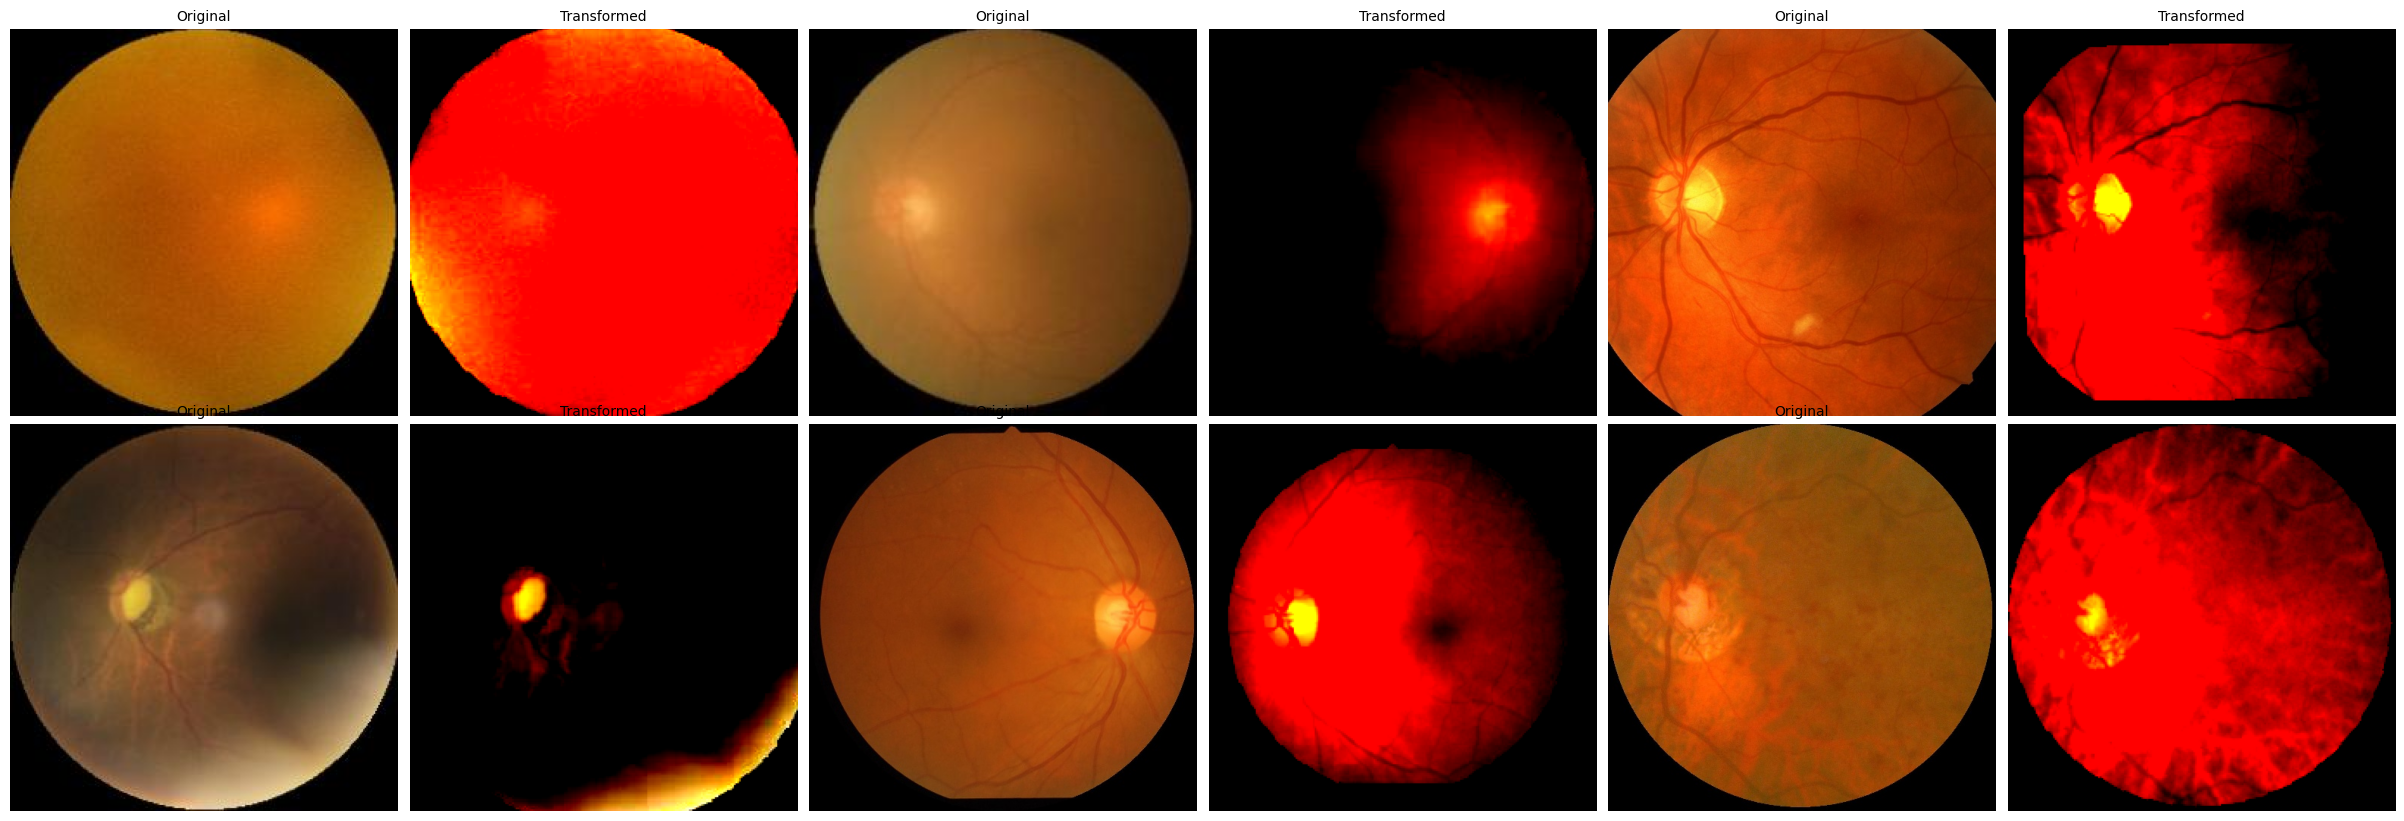

In [10]:
#@title Display Transformations

import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.datasets import ImageFolder

if use_flip or use_color_jitter or use_rotation:

  # Get the original dataset without transforms
  orig_dataset = ImageFolder(data_dir)  # no transforms

  # --- Plot side-by-side pairs ---
  fig, axes = plt.subplots(2, 6, figsize=(24, 8))  # 2 rows, 6 cols = 3 pairs per row

  for i in range(6):  # 6 pairs total
      # Random index
      idx = random.randint(0, len(full_dataset) - 1)

      # --- Original image ---
      orig_img, orig_label = orig_dataset[idx]
      orig_array = np.array(orig_img)

      # --- Transformed image ---
      c_x, c_y = full_dataset[idx]  # (transformed image, label)
      c_x_cpu = c_x.cpu().permute(1, 2, 0)  # [C, H, W] -> [H, W, C]

      # Handle grayscale repeated in 3 channels
      if c_x_cpu.shape[2] == 3 and np.allclose(c_x_cpu[:,:,0], c_x_cpu[:,:,1]) and np.allclose(c_x_cpu[:,:,1], c_x_cpu[:,:,2]):
          trans_img = c_x_cpu[:,:,0]
          cmap = 'bone'
      else:
          trans_img = c_x_cpu
          cmap = None

      # Determine subplot location
      row_idx = i // 3
      col_start = (i % 3) * 2

      # Display original
      axes[row_idx, col_start].imshow(orig_array, cmap='bone')
      axes[row_idx, col_start].set_title('Original', fontsize=10)
      axes[row_idx, col_start].axis('off')

      # Display transformed
      axes[row_idx, col_start + 1].imshow(trans_img, cmap=cmap)
      axes[row_idx, col_start + 1].set_title('Transformed', fontsize=10)
      axes[row_idx, col_start + 1].axis('off')

  plt.tight_layout(pad=0.2)
  plt.show()
else:
  print("=== SIN TRANSFORMACIONES APLICADAS ===")


In [11]:
#model = SimpleEyeDiseaseClassifer(num_classes=len(target_to_class))
#print(str(model)[:500])

In [12]:
#@title Instantiate Network

#pool_size=3, use_gap=False,linear_hidden_neurons=16, dropout_p=0.3, act='relu'
# OLD
#model = SimpleConvNet(num_classes=len(target_to_class))

import torch
import torch.nn as nn
import torchvision.models as models

# Parameters
num_classes = 4

# Load base model (pretrained on ImageNet)
base_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Enable fine-tuning (same as base_model.trainable = True)
for param in base_model.parameters():
    param.requires_grad = True

# Replace the classification head
class CustomEfficientNet(nn.Module):
    def __init__(self, base_model, num_classes):
        super(CustomEfficientNet, self).__init__()
        self.base = nn.Sequential(*list(base_model.children())[:-1])  # remove classifier
        self.bn1 = nn.BatchNorm2d(1280)  # 1280 = output channels of EfficientNetB0
        self.conv = nn.Conv2d(1280, 512, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.base(x)
        x = self.bn1(x)
        x = self.conv(x)
        x = self.relu(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.bn2(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Instantiate model
model = CustomEfficientNet(base_model, num_classes)

summary(model, input_size=(var_kernel_size, image_width, image_height), device='cpu')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 208MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

In [13]:
#@title Display Network structure
#model_graph = draw_graph(model, input_size=(1, 3, image_width, image_height))
#model_graph.visual_graph

In [14]:
#@title Loss Function and Optimizer

# Loss function
criterion = nn.CrossEntropyLoss()
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

In [15]:
#@title Balance images per class

if balancear_por_clase:
    # Paso 1: agrupar índices por clase
    indices_por_clase = defaultdict(list)
    for idx, (_, label) in enumerate(full_dataset):
        indices_por_clase[label].append(idx)

    # Paso 2: determinar cuántos usar por clase (mínimo disponible)
    min_count = min(len(lst) for lst in indices_por_clase.values())
    if min_count == 0:
        print("⚠ No se puede balancear: alguna clase no tiene registros.")
    else:
        print(f"📊 Balanceo activado. Cantidad unificada por clase: {min_count}")

        train_indices, val_indices, test_indices = [], [], []

        generator = torch.Generator().manual_seed(seed)

        for clase, idxs in indices_por_clase.items():
            # Paso 3: tomar muestra aleatoria de tamaño min_count
            idxs = torch.tensor(idxs)
            shuffled = idxs[torch.randperm(len(idxs), generator=generator)[:min_count]]

            n_train = int(min_count * train_pct)
            n_val   = int(min_count * val_pct)
            n_test  = min_count - n_train - n_val  # exact match

            train_indices.extend(shuffled[:n_train].tolist())
            val_indices.extend(shuffled[n_train:n_train+n_val].tolist())
            test_indices.extend(shuffled[n_train+n_val:].tolist())

        # Paso 4: crear datasets balanceados
        train_ds = Subset(full_dataset, train_indices)
        val_ds   = Subset(full_dataset, val_indices)
        test_ds  = Subset(full_dataset, test_indices)

else:
    # Modo normal (sin balanceo por clase)
    n = len(full_dataset)
    n_train = int(n * train_pct)
    n_val   = int(n * val_pct)
    n_test  = n - n_train - n_val  # que cierre exacto
    generator = torch.Generator().manual_seed(seed)
    train_ds, val_ds, test_ds = random_split(full_dataset, [n_train, n_val, n_test], generator=generator)

train_loader = DataLoader(train_ds, batch_size=int(var_batch_size/2), shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=var_batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=var_batch_size, shuffle=False, num_workers=0, pin_memory=True)

#TODO Balancear los registros que se tomand de cada tipo, para que sea parejo. Osea de la primara clase tomar un 80, 10, 10, de la segunda clase igual y asi...
# Creo que está

batch_size = var_batch_size  # para mostrarlo en el mensaje

print(f"📚 Entrenamiento: {len(train_loader.dataset)} muestras "
      f"→ {len(train_loader)} lotes por época (batch size = {int(batch_size/2)})")

print(f"🧪 Validación:    {len(val_loader.dataset)} muestras "
      f"→ {len(val_loader)} lotes por época (batch size = {batch_size})")

print(f"🔎 Prueba:        {len(test_loader.dataset)} muestras "
      f"→ {len(test_loader)} lotes por época (batch size = {batch_size})")


train_losses, val_losses = [], []
train_accs, val_accs     = [], []

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

# Early stopper: para val_loss usamos mode='min'
early_stopper = EarlyStopping(patience=patience, min_delta=0.001, mode='min', restore_best=True)


📊 Balanceo activado. Cantidad unificada por clase: 1007
📚 Entrenamiento: 3220 muestras → 403 lotes por época (batch size = 8)
🧪 Validación:    400 muestras → 25 lotes por época (batch size = 16)
🔎 Prueba:        408 muestras → 26 lotes por época (batch size = 16)


In [16]:
#@title Train and Validation Phases

for epoch in range(num_epochs):
    model.train()
    running_loss  = 0.0
    train_total   = 0
    train_correct = 0

    train_true_labels = []
    train_pred_probabilities = []

    for images, labels in tqdm(train_loader, desc='Training'):
        images, labels = images.to(device), labels.to(device)

        # Reset accumulated gradients in model parameters
        optimizer.zero_grad()

        # Forward pass: model predictions for the batch
        outputs = model(images)

        # Compute loss comparing predictions vs labels
        loss = criterion(outputs, labels)

        # Backpropagation: compute gradients d(loss)/d(param)
        loss.backward()

        # Gradient clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update parameters using the optimizer
        optimizer.step()

        # Accumulate loss * batch size (for later averaging)
        running_loss += loss.item() * labels.size(0)

        # Calculate training accuracy
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        # For ROC and confusion matrix
        probs = torch.softmax(outputs, dim=1)  # Apply softmax HERE for probabilities
        train_true_labels.extend(labels.detach().cpu().tolist())
        train_pred_probabilities.extend(probs.detach().cpu().numpy())

    # Average training loss per example
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = train_correct / train_total if train_total > 0 else 0.0

    # Save training metrics
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ========== Validation Phase ==========
    model.eval()
    running_loss = 0.0
    val_correct  = 0
    val_total    = 0

    # Labels and probabilities for ROC
    val_true_labels = []
    val_pred_probabilities = []

    with torch.no_grad():  # No gradients in validation (saves memory and time)
        for images, labels in tqdm(val_loader, desc='Validation'):
            # Move inputs and labels to the device
            images, labels = images.to(device), labels.to(device)

            # Forward pass in validation
            outputs = model(images)

            # Calculate validation loss for the batch
            loss = criterion(outputs, labels)

            # Accumulate loss weighted by batch size
            running_loss += loss.item() * labels.size(0)

            # Validation accuracy
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            # For ROC and confusion matrix
            probs = torch.softmax(outputs, dim=1)  # Apply softmax HERE for probabilities
            val_true_labels.extend(labels.detach().cpu().tolist())
            val_pred_probabilities.extend(probs.detach().cpu().numpy())

    # Average validation loss per example
    val_loss = running_loss / len(val_loader.dataset)
    val_acc = val_correct / val_total if val_total > 0 else 0.0

    # Save validation metrics
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Step the learning rate scheduler
    scheduler.step(val_loss)

    # Get current learning rate for logging
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch+1}/{num_epochs} - "
        f"Tra_Accuracy: {train_acc:.4f} - Tra_Loss: {train_loss:.4f} - "
        f"Val_Accuracy: {val_acc:.4f} - Val_Loss: {val_loss:.4f} - "
        f"LR: {current_lr:.6f}"  # Show current learning rate
    )

    # Early stopping check
    if early_stopper.step(val_loss, model):
        print(f"⛔ Early stopping at epoch {epoch+1} (no improvements for {early_stopper.patience} epochs).")
        break

print("\n✅ Training completed!")
print(f"Best train loss: {min(train_losses):.4f} at epoch {train_losses.index(min(train_losses))+1}")
print(f"Best train accuracy: {max(train_accs):.4f} at epoch {train_accs.index(max(train_accs))+1}")
print(f"Best validation loss: {min(val_losses):.4f} at epoch {val_losses.index(min(val_losses))+1}")
print(f"Best validation accuracy: {max(val_accs):.4f} at epoch {val_accs.index(max(val_accs))+1}")

Training:   0%|          | 0/403 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/100 - Tra_Accuracy: 0.7084 - Tra_Loss: 0.7452 - Val_Accuracy: 0.8650 - Val_Loss: 0.3950 - LR: 0.000100


Training:   0%|          | 0/403 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 30/100 - Tra_Accuracy: 0.9870 - Tra_Loss: 0.0538 - Val_Accuracy: 0.9325 - Val_Loss: 0.3432 - LR: 0.000003


Training:   0%|          | 0/403 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 31/100 - Tra_Accuracy: 0.9876 - Tra_Loss: 0.0380 - Val_Accuracy: 0.9400 - Val_Loss: 0.2907 - LR: 0.000003
⛔ Early stopping at epoch 31 (no improvements for 15 epochs).

✅ Training completed!
Best train loss: 0.0340 at epoch 26
Best train accuracy: 0.9894 at epoch 25
Best validation loss: 0.2000 at epoch 16
Best validation accuracy: 0.9525 at epoch 28


In [17]:
#@title Test Phase

test_true_labels = []
test_pred_probabilities = []
correctas = 0
total_muestras = 0

with torch.no_grad():
    for imagenes, etiquetas in tqdm(test_loader, desc='Test'):
        imagenes, etiquetas = imagenes.to(device, non_blocking=True), etiquetas.to(device, non_blocking=True)
        salidas = model(imagenes)
        _, predicciones = torch.max(salidas, 1)


        # Para ROC y Matriz de confusión
        probs = torch.softmax(salidas, dim=1)
        test_true_labels.extend(etiquetas.detach().cpu().tolist())
        test_pred_probabilities.extend(probs.detach().cpu().numpy())
        #######

        correctas += (predicciones == etiquetas).sum().item()
        total_muestras += etiquetas.size(0)

Test:   0%|          | 0/26 [00:00<?, ?it/s]

✅ Modelo restaurado al mejor estado según validación.


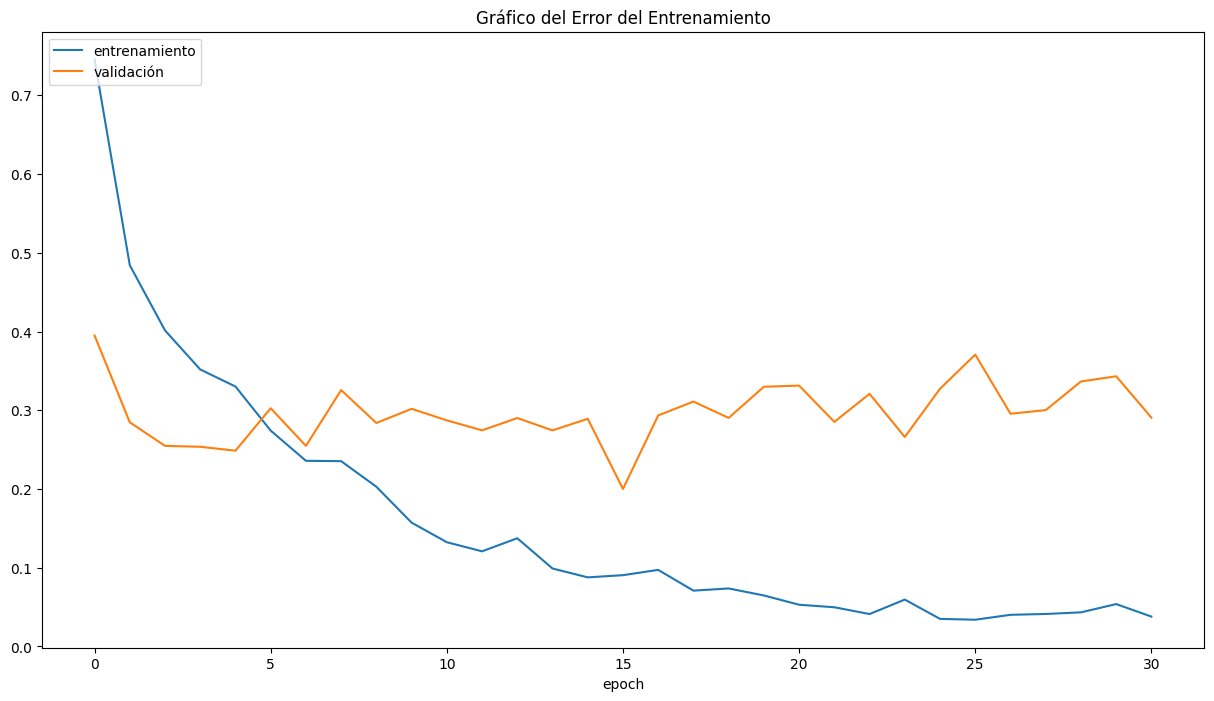

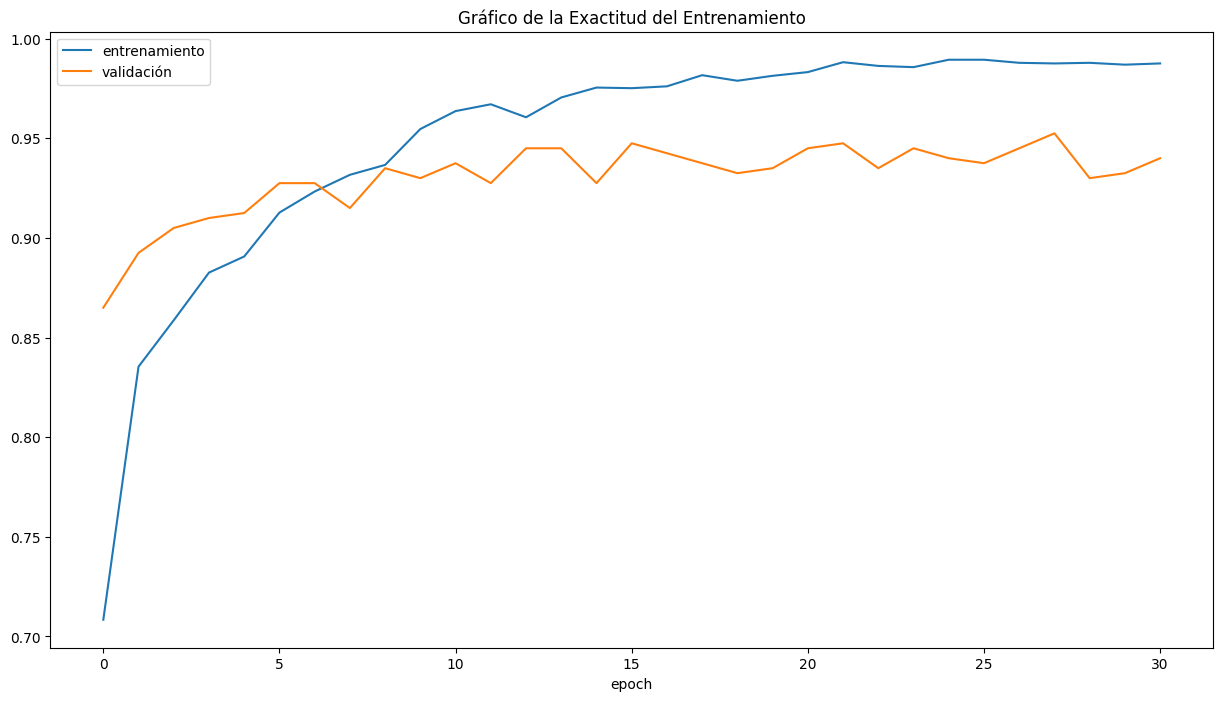

In [18]:
#@title Save Model and Display Error Graphs

# Restaurar mejores pesos (si corresponde)
early_stopper.restore(model)
print("✅ Modelo restaurado al mejor estado según validación.")

# Guardar
torch.save(model.state_dict(), "modelo_cnn.pth")

plt.figure(figsize=(15,8))
plt.plot(train_losses)
plt.plot(val_losses)
plt.title('Gráfico del Error del Entrenamiento')
plt.ylabel('')
plt.xlabel('epoch')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

plt.figure(figsize=(15,8))
plt.plot(train_accs)
plt.plot(val_accs)
plt.title('Gráfico de la Exactitud del Entrenamiento')
plt.ylabel('')
plt.xlabel('epoch')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

In [19]:
#@title Precision Evaluation Summary

precision_final = correctas / total_muestras
print(f"\n--- Resultados de la Evaluación Final de la CNN ---")
print(f"Total de imágenes evaluadas: {total_muestras}")
print(f"Imágenes clasificadas correctamente: {correctas}")
print(f"Precisión FINAL del modelo CNN en todas las imágenes válidas: {precision_final:.4f}")


--- Resultados de la Evaluación Final de la CNN ---
Total de imágenes evaluadas: 408
Imágenes clasificadas correctamente: 381
Precisión FINAL del modelo CNN en todas las imágenes válidas: 0.9338


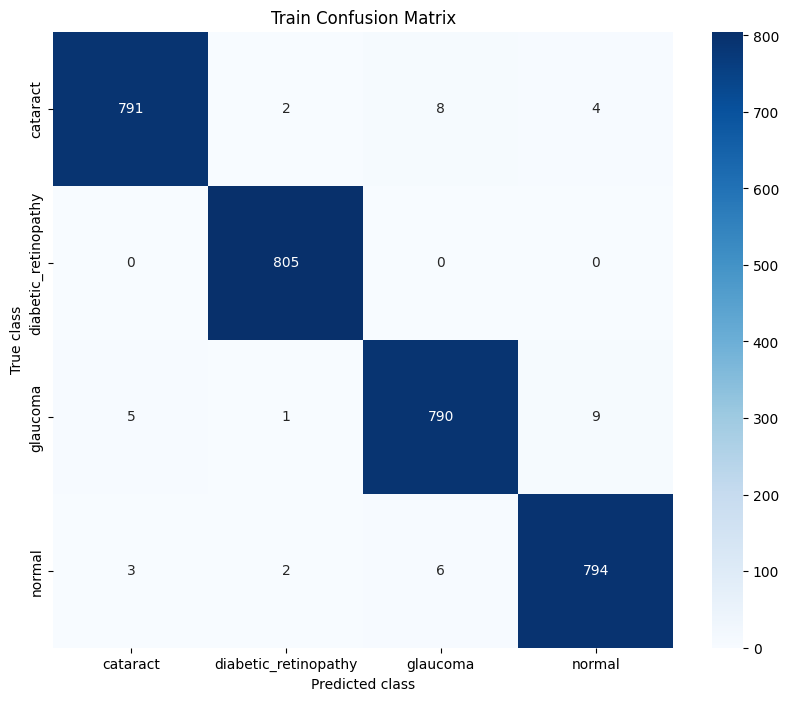

Train Accuracy: 0.988
Train samples: 3220

Train Detailed Metrics:
                      precision    recall  f1-score   support

            cataract      0.990     0.983     0.986       805
diabetic_retinopathy      0.994     1.000     0.997       805
            glaucoma      0.983     0.981     0.982       805
              normal      0.984     0.986     0.985       805

            accuracy                          0.988      3220
           macro avg      0.988     0.988     0.988      3220
        weighted avg      0.988     0.988     0.988      3220



In [20]:
#@title Train Confusion Matrix + Metrics

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

classes_names = list(target_to_class.values())

# Convert probabilities to hard predictions (same as ROC curves use)
train_hard_predictions = np.argmax(train_pred_probabilities, axis=1)

# Create confusion matrix with same data as ROC
train_cm = confusion_matrix(train_true_labels, train_hard_predictions,
                          labels=list(range(len(classes_names))))

# Plot the train confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title(f'Train Confusion Matrix')
plt.savefig("Train_confusion_matrix.png")
plt.show()

# Calculate train metrics
train_accuracy = accuracy_score(train_true_labels, train_hard_predictions)
print(f"Train Accuracy: {train_accuracy:.3f}")
print(f"Train samples: {len(train_true_labels)}")

# Detailed classification report
print("\nTrain Detailed Metrics:")
print(classification_report(train_true_labels, train_hard_predictions,
                          target_names=classes_names, digits=3))



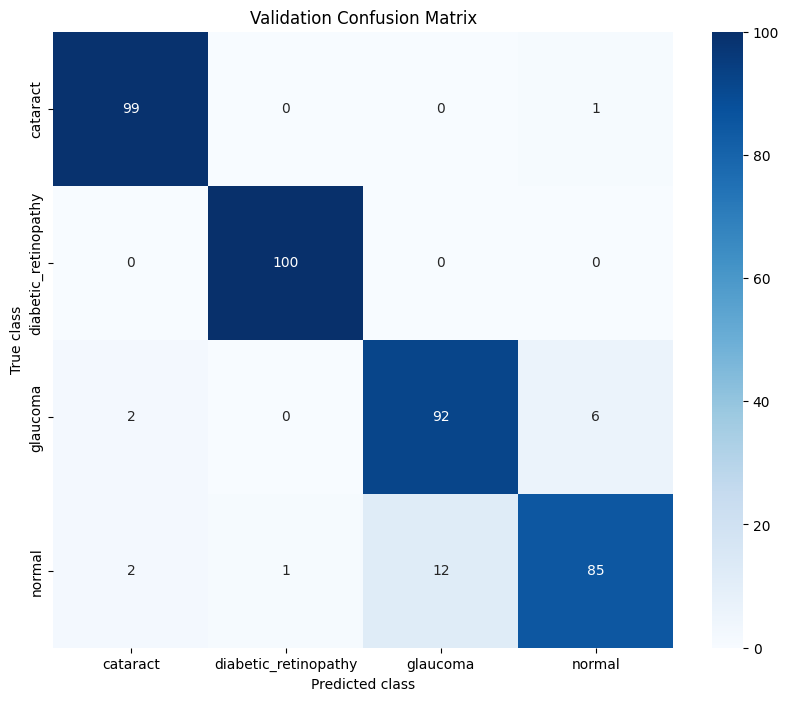

Validation Accuracy: 0.940
Validation samples: 400

Validation Detailed Metrics:
                      precision    recall  f1-score   support

            cataract      0.961     0.990     0.975       100
diabetic_retinopathy      0.990     1.000     0.995       100
            glaucoma      0.885     0.920     0.902       100
              normal      0.924     0.850     0.885       100

            accuracy                          0.940       400
           macro avg      0.940     0.940     0.939       400
        weighted avg      0.940     0.940     0.939       400



In [21]:
#@title Validation Confusion Matrix + Metrics

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

classes_names = list(target_to_class.values())

# Convert probabilities to hard predictions (same as ROC curves use)
val_hard_predictions = np.argmax(val_pred_probabilities, axis=1)

# Create confusion matrix with same data as ROC
val_cm = confusion_matrix(val_true_labels, val_hard_predictions,
                          labels=list(range(len(classes_names))))

# Plot the validation confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title(f'Validation Confusion Matrix')
plt.savefig("Validation_confusion_matrix.png")
plt.show()

# Calculate validation metrics
val_accuracy = accuracy_score(val_true_labels, val_hard_predictions)
print(f"Validation Accuracy: {val_accuracy:.3f}")
print(f"Validation samples: {len(val_true_labels)}")

# Detailed classification report
print("\nValidation Detailed Metrics:")
print(classification_report(val_true_labels, val_hard_predictions,
                          target_names=classes_names, digits=3))



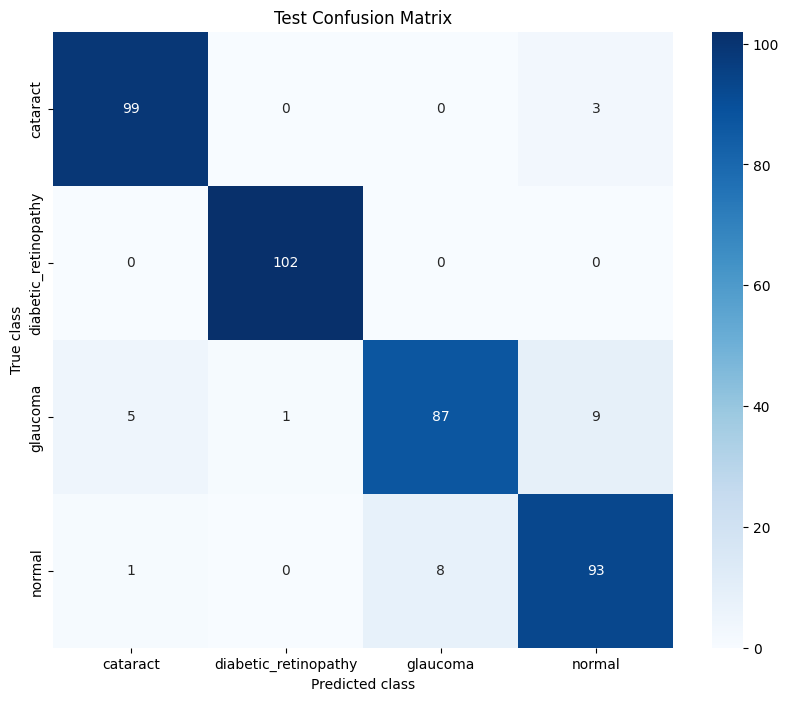

Test Accuracy: 0.934
Test samples: 408

Test Detailed Metrics:
                      precision    recall  f1-score   support

            cataract      0.943     0.971     0.957       102
diabetic_retinopathy      0.990     1.000     0.995       102
            glaucoma      0.916     0.853     0.883       102
              normal      0.886     0.912     0.899       102

            accuracy                          0.934       408
           macro avg      0.934     0.934     0.933       408
        weighted avg      0.934     0.934     0.933       408



In [22]:
#@title Test Confusion Matrix

# Create test confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

classes_names = list(target_to_class.values())

# Convert probabilities to hard predictions (same as ROC curves use)
test_hard_predictions = np.argmax(test_pred_probabilities, axis=1)

# Create confusion matrix with same data as ROC
test_cm = confusion_matrix(test_true_labels, test_hard_predictions,
                          labels=list(range(len(classes_names))))

# Plot the test confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title(f'Test Confusion Matrix')
plt.savefig("test_confusion_matrix.png")
plt.show()

# Calculate test metrics
test_accuracy = accuracy_score(test_true_labels, test_hard_predictions)
print(f"Test Accuracy: {test_accuracy:.3f}")
print(f"Test samples: {len(test_true_labels)}")

# Detailed classification report
print("\nTest Detailed Metrics:")
print(classification_report(test_true_labels, test_hard_predictions,
                          target_names=classes_names, digits=3))




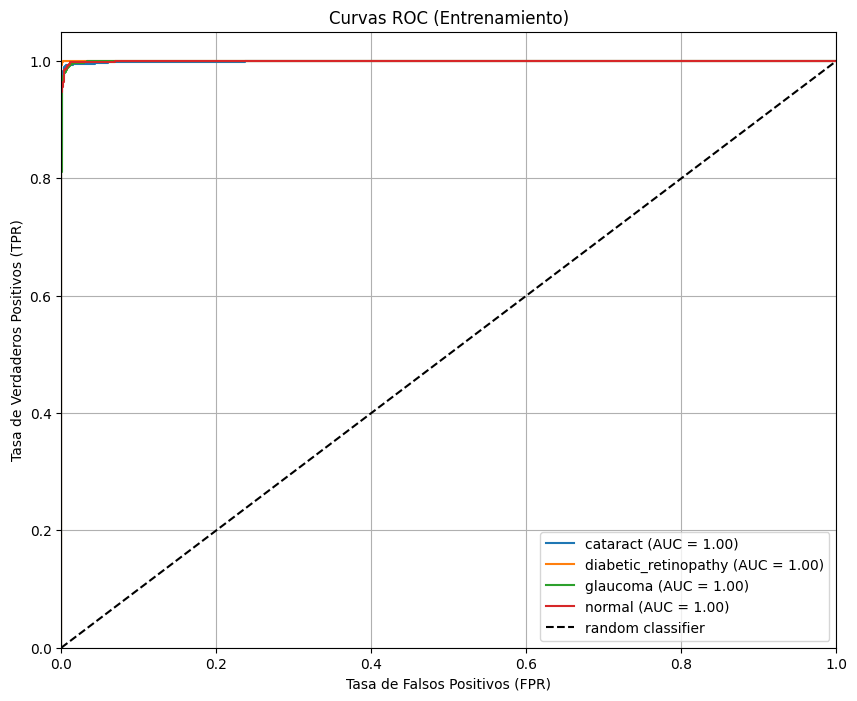

ROC AUC Macro-average: 1.000
ROC AUC Weighted-average: 1.000


In [23]:
      #@title ROC Train Curves

from sklearn.metrics import roc_auc_score

# Calcular la curva ROC y el AUC para cada clase
plt.figure(figsize=(10, 8))
fpr = dict()
tpr = dict()
roc_auc = dict()
classes_names = list(target_to_class.values())

for i in range(len(classes_names)):
    fpr[i], tpr[i], _ = roc_curve(np.array(train_true_labels) == i, np.array(train_pred_probabilities)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Graficar la curva ROC para cada clase
for i in range(len(classes_names)):
    label_name = classes_names[i]
    plt.plot(fpr[i], tpr[i], label=f'{label_name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC (Entrenamiento)')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("train_roc_curves.png")
plt.show()

# Convert to numpy arrays
y_true = np.array(train_true_labels)
y_score = np.array(train_pred_probabilities)

# Compute macro-average ROC AUC (one-vs-rest)
roc_auc_macro = roc_auc_score(y_true, y_score, multi_class='ovr', average='macro')
roc_auc_weighted = roc_auc_score(y_true, y_score, multi_class='ovr', average='weighted')

print(f"ROC AUC Macro-average: {roc_auc_macro:.3f}")
print(f"ROC AUC Weighted-average: {roc_auc_weighted:.3f}")


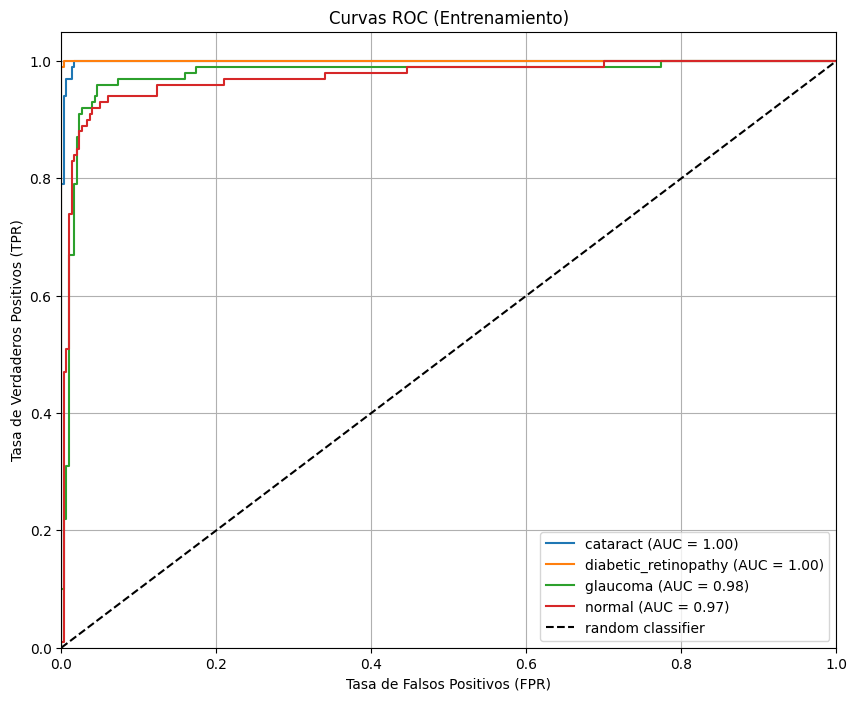

ROC AUC Macro-average: 0.987
ROC AUC Weighted-average: 0.987


In [24]:
      #@title ROC Validation Curves

from sklearn.metrics import roc_auc_score

# Calcular la curva ROC y el AUC para cada clase
plt.figure(figsize=(10, 8))
fpr = dict()
tpr = dict()
roc_auc = dict()
classes_names = list(target_to_class.values())

for i in range(len(classes_names)):
    fpr[i], tpr[i], _ = roc_curve(np.array(val_true_labels) == i, np.array(val_pred_probabilities)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Graficar la curva ROC para cada clase
for i in range(len(classes_names)):
    label_name = classes_names[i]
    plt.plot(fpr[i], tpr[i], label=f'{label_name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC (Entrenamiento)')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("validation_roc_curves.png")
plt.show()

# Convert to numpy arrays
y_true = np.array(val_true_labels)
y_score = np.array(val_pred_probabilities)

# Compute macro-average ROC AUC (one-vs-rest)
roc_auc_macro = roc_auc_score(y_true, y_score, multi_class='ovr', average='macro')
roc_auc_weighted = roc_auc_score(y_true, y_score, multi_class='ovr', average='weighted')

print(f"ROC AUC Macro-average: {roc_auc_macro:.3f}")
print(f"ROC AUC Weighted-average: {roc_auc_weighted:.3f}")


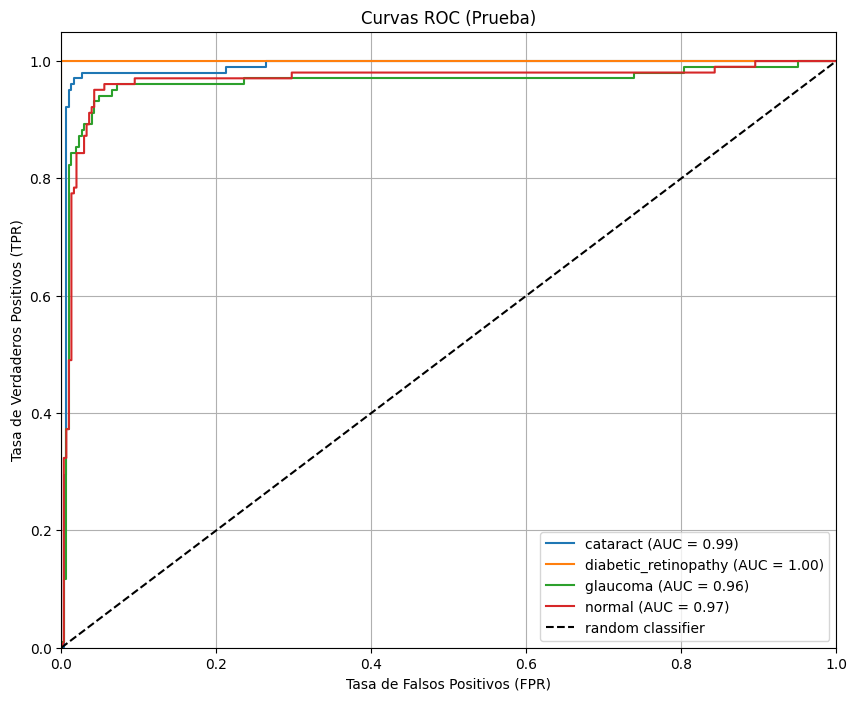

ROC AUC Macro-average: 0.980
ROC AUC Weighted-average: 0.980


In [25]:
#@title ROC Test Curves

from sklearn.metrics import roc_auc_score

# Calcular la curva ROC y el AUC para cada clase
plt.figure(figsize=(10, 8))
fpr = dict()
tpr = dict()
roc_auc = dict()
classes_names = list(target_to_class.values())

for i in range(len(classes_names)):
    fpr[i], tpr[i], _ = roc_curve(np.array(test_true_labels) == i, np.array(test_pred_probabilities)[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Graficar la curva ROC para cada clase
for i in range(len(classes_names)):
    label_name = classes_names[i]
    plt.plot(fpr[i], tpr[i], label=f'{label_name} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC (Prueba)')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("test_roc_curves.png")
plt.show()

# Convert to numpy arrays
y_true = np.array(test_true_labels)
y_score = np.array(test_pred_probabilities)

# Compute macro-average ROC AUC (one-vs-rest)
roc_auc_macro = roc_auc_score(y_true, y_score, multi_class='ovr', average='macro')
roc_auc_weighted = roc_auc_score(y_true, y_score, multi_class='ovr', average='weighted')

print(f"ROC AUC Macro-average: {roc_auc_macro:.3f}")
print(f"ROC AUC Weighted-average: {roc_auc_weighted:.3f}")
